In [1]:
import tensorflow as tf
import cv2
import numpy as np

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.15.0
OpenCV: 4.9.0
GPU Available: []


## Loading The Data

In [3]:
import kagglehub

path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")
print("Path to dataset files:", path)

100%|██████████| 3.58G/3.58G [13:53<00:00, 4.62MB/s] 

Extracting files...


Path to dataset files: /Users/parivat/.cache/kagglehub/datasets/sriramr/fruits-fresh-and-rotten-for-classification/versions/1


In [11]:
import shutil
import os

base_path = os.path.join(path, "dataset")
binary_path = os.path.join(os.getcwd(), "binary_dataset")  # local path instead of /content/

for split in ["train", "test"]:
    for cls in ["fresh", "rotten"]:
        os.makedirs(os.path.join(binary_path, split, cls), exist_ok=True)

for split in ["train", "test"]:
    src_split = os.path.join(base_path, split)
    for folder in os.listdir(src_split):
        src_folder = os.path.join(src_split, folder)
        label = "fresh" if folder.startswith("fresh") else "rotten"
        dst_folder = os.path.join(binary_path, split, label)
        for file in os.listdir(src_folder):
            shutil.copy(os.path.join(src_folder, file), dst_folder)

print("Done reorganizing!")

Done reorganizing!


In [12]:
train_dir = os.path.join(binary_path, "train")
test_dir = os.path.join(binary_path, "test")

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 8721 images belonging to 2 classes.
Found 2180 images belonging to 2 classes.
Found 2698 images belonging to 2 classes.


In [14]:
print(train_generator.class_indices)

{'fresh': 0, 'rotten': 1}


# Model Training via (Feature Extraction.)

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    BatchNormalization, SeparableConv2D, Conv2D, MaxPooling2D,
    Dropout, Flatten, Dense, Input
)
from tensorflow.keras.models import Model

# 1. Load MobileNetV2 as base (frozen, no top layers)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze base model layers

# 2. Build custom head on top
x = base_model.output
x = BatchNormalization()(x)

x = SeparableConv2D(64, (3,3), activation='relu', padding='same')(x)
x = SeparableConv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2,2))(x)
x = Dropout(0.4)(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)
x = Dropout(0.5)(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

# 3. Create final model
model = Model(inputs=base_model.input, outputs=output)

model.summary()

9406464/9406464 [==============================] - 1s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (N

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

In [18]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
273/273 [==============================] - 125s 454ms/step - loss: 0.1437 - accuracy: 0.9442 - val_loss: 0.0509 - val_accuracy: 0.9812
Epoch 2/20


/Users/parivat/Desktop/cllg_proj/venv/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


273/273 [==============================] - 173s 634ms/step - loss: 0.0598 - accuracy: 0.9782 - val_loss: 0.0306 - val_accuracy: 0.9894
Epoch 3/20
273/273 [==============================] - 228s 837ms/step - loss: 0.0504 - accuracy: 0.9825 - val_loss: 0.0166 - val_accuracy: 0.9936
Epoch 4/20
273/273 [==============================] - 270s 990ms/step - loss: 0.0409 - accuracy: 0.9858 - val_loss: 0.0130 - val_accuracy: 0.9954
Epoch 5/20
273/273 [==============================] - 307s 1s/step - loss: 0.0329 - accuracy: 0.9880 - val_loss: 0.0095 - val_accuracy: 0.9968
Epoch 6/20
273/273 [==============================] - 337s 1s/step - loss: 0.0271 - accuracy: 0.9906 - val_loss: 0.0073 - val_accuracy: 0.9986
Epoch 7/20
273/273 [==============================] - 311s 1s/step - loss: 0.0247 - accuracy: 0.9916 - val_loss: 0.0150 - val_accuracy: 0.9950
Epoch 8/20
273/273 [==============================] - 325s 1s/step - loss: 0.0225 - accuracy: 0.9923 - val_loss: 0.0034 - val_accuracy: 0.9986
E

In [19]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


85/85 [==============================] - 32s 371ms/step - loss: 0.0185 - accuracy: 0.9956
Test Loss: 0.0185
Test Accuracy: 0.9956


# Evaluation Matrix

85/85 [==============================] - 21s 234ms/step
              precision    recall  f1-score   support

       fresh       0.99      1.00      0.99      1164
      rotten       1.00      0.99      1.00      1534

    accuracy                           1.00      2698
   macro avg       1.00      1.00      1.00      2698
weighted avg       1.00      1.00      1.00      2698



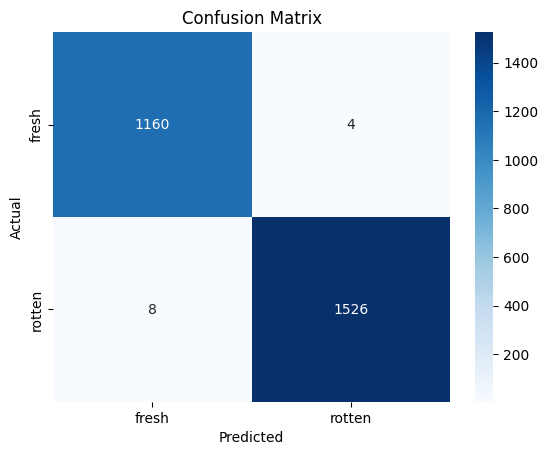

In [21]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

# Classification report
print(classification_report(true_classes, predicted_classes, target_names=['fresh', 'rotten']))

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fresh','rotten'], yticklabels=['fresh','rotten'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
import os
print(os.path.exists('best_model.h5'))
print(round(os.path.getsize('best_model.h5') / (1024*1024), 2), "MB")

True
13.05 MB
